<a href="https://colab.research.google.com/github/Nadaramadan1/Assignment_Week-2/blob/main/Coding_Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [29]:
img = cv2.imread('/content/evgeni-tcherkasski-c659bBmJpw0-unsplash.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

In [30]:
# 3. Histogram Equalization
eq_global = cv2.equalizeHist(gray)

# 4. CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
eq_clahe = clahe.apply(gray)

# 5. Gamma Correction
def gamma_correction(img, gamma):
    table = np.array([
        ((i / 255.0) ** gamma) * 255
        for i in range(256)
    ]).astype("uint8")

    return cv2.LUT(img, table)

bright = gamma_correction(gray, 0.5)
dark = gamma_correction(gray, 2.0)


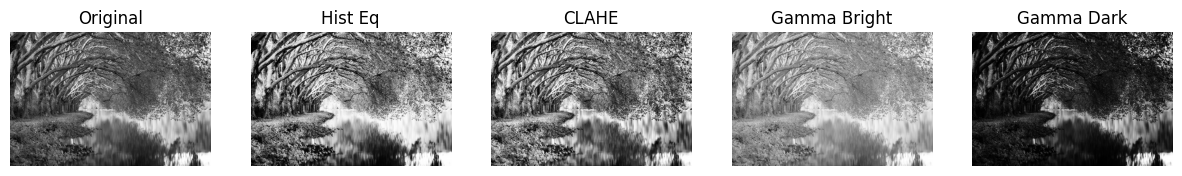

In [31]:
# 6. Plot Images
titles = ['Original', 'Hist Eq', 'CLAHE', 'Gamma Bright', 'Gamma Dark']
images = [gray, eq_global, eq_clahe, bright, dark]

plt.figure(figsize=(15,5))

for i in range(len(images)):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()


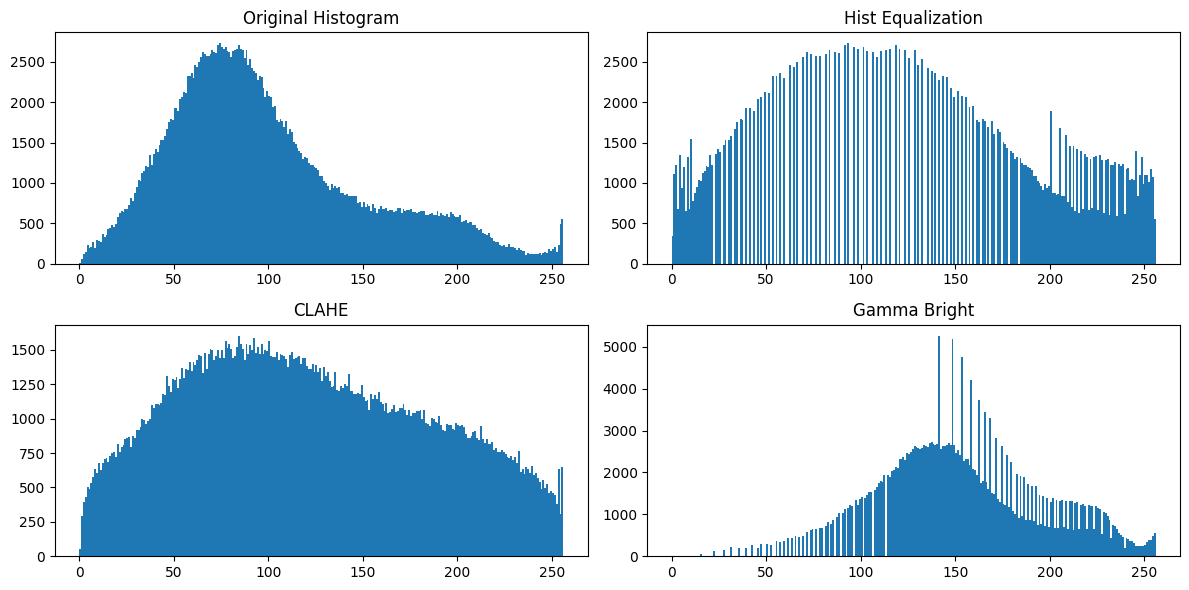

In [32]:
# 7. Plot Histograms
plt.figure(figsize=(12,6))

# Original Histogram
plt.subplot(2,2,1)
plt.hist(gray.ravel(), bins=256, range=[0,256])
plt.title("Original Histogram")

# Global Equalization Histogram
plt.subplot(2,2,2)
plt.hist(eq_global.ravel(), bins=256, range=[0,256])
plt.title("Hist Equalization")

# CLAHE Histogram
plt.subplot(2,2,3)
plt.hist(eq_clahe.ravel(), bins=256, range=[0,256])
plt.title("CLAHE")

# Gamma Histogram
plt.subplot(2,2,4)
plt.hist(bright.ravel(), bins=256, range=[0,256])
plt.title("Gamma Bright")

plt.tight_layout()
plt.show()